In [2]:
import numpy as np
import cv2
import keras
import tensorflow as tf
import keras.backend.tensorflow_backend as KTF
from keras import optimizers
from keras.optimizers import *
from keras import regularizers
from keras.models import *
from keras.engine import InputSpec
from keras.layers import Input, Add, Lambda, Subtract, Reshape, Dense
from math import pi as pi
%matplotlib inline
import matplotlib.pyplot as plt
import os
import scipy.io as scio  # mat
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'simulations':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from functions.project_paths import project_path
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
config = tf.ConfigProto()
config.gpu_options.allow_growth=True
sess = tf.Session(config=config)
KTF.set_session(sess)


def spiral_kxky(filename, ledNum):
    kxky = [[], []]
    with open(filename, 'r') as file:
        for line in file:
            for j, value in enumerate(line.split(",")):
                kxky[j].append(np.float(value))
    kxky = np.asarray(kxky)
    kxky = kxky.T
    return kxky[:ledNum, :]


In [3]:

def show_result(model, show=0, noShow=10):
    #obj
    w_conv_Or = model.get_layer('Or').get_weights()
    w_conv_Oi = model.get_layer('Oi').get_weights()
    w_conv_Or_array = np.asarray(w_conv_Or)
    w_conv_Oi_array = np.asarray(w_conv_Oi)
    c_real = w_conv_Or_array[0, :, :, 0].reshape((imSize, imSize))
    c_imag = w_conv_Oi_array[0, :, :, 0].reshape((imSize, imSize))  
    c_complex = np.fft.ifft2(np.fft.ifftshift(c_real + 1j * c_imag))
    c_abs = np.abs(c_complex)
    c_phase = np.angle(c_complex)
    objFTLog1 = np.log(np.abs(c_real + 1j * c_imag) + 1)
    objFTLog2 = np.log(np.abs(obj_fft) + 1)
    
    #psf
    w_conv_psfr = np.asarray( model.get_layer('Pr').get_weights() )
    w_conv_psfi = np.asarray( model.get_layer('Pi').get_weights() )
    pupil_rho = w_conv_psfr[0, :, :, 0].reshape((imSize, imSize)) 
    temp = w_conv_psfi[:, :, :].reshape((1,1,zernike_number))
    pupil_imag = np.multiply( temp ,  zernike_poly)
    pupil_phi = np.sum(pupil_imag,axis = -1)
    
    p_amp = np.abs(pupil_rho)
    p_phi = np.mod(pupil_phi +  pi , 2 * pi) * CTF - pi
    #p_phi = pupil_phi
    
    ang1 = p_phi
    ang2 = np.angle(CTF*pupil)
    ang2 = np.mod(ang2 * CTF +  pi , 2 * pi) * CTF - pi
    
    if show:
        plt.figure()
        plt.subplot(231),plt.imshow(c_abs[noShow:imSize-noShow, noShow:imSize-noShow], cmap='gray'),plt.title('1recover (abs)'),plt.xticks([]),plt.yticks([])
        plt.subplot(232),plt.imshow(c_phase[noShow:imSize-noShow, noShow:imSize-noShow], cmap='gray'),plt.title('recover (phase)'),plt.xticks([]),plt.yticks([])
        plt.subplot(233),plt.imshow(objFTLog1[noShow:imSize-noShow, noShow:imSize-noShow], cmap='gray'),plt.title('recover FT'),plt.xticks([]),plt.yticks([])
        plt.subplot(234),plt.imshow(np.abs(obj[noShow:imSize-noShow, noShow:imSize-noShow]), cmap='gray'),plt.title('high res (abs)'),plt.xticks([]),plt.yticks([])
        plt.subplot(235),plt.imshow(np.angle(obj[noShow:imSize-noShow, noShow:imSize-noShow]), cmap='gray'),plt.title('high res (phase)'),plt.xticks([]),plt.yticks([])
        plt.subplot(236),plt.imshow(objFTLog2[noShow:imSize-noShow, noShow:imSize-noShow], cmap='gray'),plt.title('high res FT'),plt.xticks([]),plt.yticks([])
        plt.show()
        
        plt.figure()
        plt.subplot(231),plt.imshow(pupil_rho,cmap='gray'),plt.title('Zernike:recover CTF abs'),plt.xticks([]),plt.yticks([])
        plt.subplot(232),plt.imshow(np.abs(CTF*pupil)[noShow:imSize-noShow, noShow:imSize-noShow],cmap='gray'),plt.title('real CTF abs'),plt.xticks([]),plt.yticks([])
        plt.subplot(233),plt.imshow(np.abs(np.abs(CTF*pupil) - np.abs(pupil_rho)),cmap='gray'),plt.title('Minus'),plt.xticks([]),plt.yticks([])
        plt.subplot(234),plt.imshow(ang1, cmap='gray'),plt.title('Recover CTF phase'),plt.xticks([]),plt.yticks([])
        plt.subplot(235),plt.imshow(ang2, cmap='gray'),plt.title('Real CTF phase'),plt.xticks([]),plt.yticks([])
        plt.subplot(236),plt.imshow(np.abs(ang2-ang1), cmap='gray'),plt.title('Minus'),plt.xticks([]),plt.yticks([])
    print('Show Image Sucess!')
    
        

In [4]:
# Self-define Layer
from keras.layers import Layer
class MyLayer_OBJ(Layer):

    def __init__(self, output_dims, **kwargs):
        self.output_dims = output_dims

        super(MyLayer_OBJ, self).__init__(**kwargs)

    def build(self, input_shape):
        # Create a trainable weight variable for this layer.
        self.kernel = self.add_weight(name='kernel',
                                      shape=self.output_dims,
                                      initializer='ones',
                                      trainable=True)

        super(MyLayer_OBJ, self).build(input_shape)  # Be sure to call this somewhere!

    def call(self, x):
        return x*self.kernel

    def compute_output_shape(self, input_shape):
        tup1 = (input_shape[0],)
        tup2 = self.output_dims
        tup = tup1 + tup2
        #(input_shape[0] + self.output_dims)
        return tup
    
class MyLayer_PUP(Layer):

    def __init__(self, output_dims, **kwargs):
        self.output_dims = output_dims

        super(MyLayer_PUP, self).__init__(**kwargs)

    def build(self, input_shape):
        # Create a trainable weight variable for this layer.
        self.kernel = self.add_weight(name='kernel',
                                      shape=self.output_dims,
                                      initializer='ones',
                                      trainable=True)

        super(MyLayer_PUP, self).build(input_shape)  # Be sure to call this somewhere!

    def call(self, x):
        return x*self.kernel

    def compute_output_shape(self, input_shape):
        tup1 = (input_shape[0],)
        tup2 = self.output_dims
        tup = tup1 + tup2
        #(input_shape[0] + self.output_dims)
        return tup


In [5]:
def define_zernike(zernike_number,kmax,imSize,CTF):
    temp_mesh = np.linspace(-kmax,kmax,num=imSize,endpoint=True) 
    kYY,kXX = np.meshgrid(temp_mesh,temp_mesh)
    CTF_logic = CTF > 0
    Zernike_logic = np.logical_not(CTF_logic)
    
    ##define the Zernike polynomials
    # Set parameters
    cutnumber = 20 #casual numbers , not important
    #zernike_number = 10 # the numbers of zernike polyminals that needed
    isnorm = 0 #normalized zernike function

    #0.get the n,m numbers
    n = []
    m = []
    for nn in range(cutnumber):
        for mm in range(-cutnumber,cutnumber+1):
            temp = nn - abs(mm)
            if  ( np.mod(temp,2)==0 and nn>=np.abs(mm) ):
                n = np.append(n,nn) #cutnumber = 20 ,the length of n is about 200
                m = np.append(m,mm)

    #1.get the radius and theta
    kxm = kXX
    kym = kYY
    km  = kxm + 1j * kym   
    km[Zernike_logic]  = 0
    theta  = np.angle(km)
    r   = np.abs(km)
    r   = r / np.max(np.max(r))
    temp_theta = theta[CTF_logic]
    temp_rho   = r[CTF_logic]

    #2.Pre-compute the values of r raised to the required powers
    rpowers = [] #the required powers of r
    temp = np.shape(m)
    for i in range(temp[0]):
        mid = np.ogrid[np.abs(m[i]):n[i]+2:2]
        rpowers = np.append(rpowers,mid) 
    rpowers = np.unique(rpowers)

    temp0 = np.shape(rpowers)
    temp1 = np.shape(temp_theta)
    pre_compute_rho = np.zeros((temp0[0],temp1[0]),dtype = np.float32) # the values of r raised to the required powers
    for i in range(temp0[0]):
        pre_compute_rho[i,:] = temp_rho ** rpowers[i]

    #3.compute the values of polynominals
    temp_zernike_number = 15
    temp0 = temp_zernike_number
    temp1 = np.shape(temp_theta)
    z     = np.zeros((temp0,temp1[0]),dtype = np.float32)
    for i in range(temp_zernike_number):
        temp = int( ( n[i] - np.abs(m[i]) )/2  )
        for k in range(temp+1):
            index = int( n[i] - 2 * k )#rpowers belongs[0,19]
            coefficient = ((-1.)**k*np.math.factorial(n[i]-k))/(np.math.factorial(k)*
                                                            np.math.factorial((n[i]+np.abs(m[i]))/2.-k)*np.math.factorial((n[i]-np.abs(m[i]))/2.-k))
            z[i,:] = z[i,:] + coefficient * pre_compute_rho[index,:]

        if isnorm :  # normalized
            z[i,:] = z[i,:] * np.sqrt( (n[i]+1) * (1 + (m[i]!=0)) / pi )

        if m[i] > 0:
            z[i,:] = z[i,:] * np.cos( np.abs(m[i]) * temp_theta )

        if m[i] < 0:
            z[i,:] = z[i,:] * np.sin( np.abs(m[i]) * temp_theta )

    temp_zernike_poly = np.zeros((imSize, imSize, temp_zernike_number),dtype=np.float32)
    zernike_poly = np.zeros((imSize, imSize, zernike_number),dtype=np.float32)
    for i in range(temp_zernike_number):
        temp = temp_zernike_poly[:,:,i]
        temp[CTF_logic] = z[i,:]
        temp_zernike_poly[:,:,i] = temp

    zernike_poly = temp_zernike_poly[:,:,:zernike_number]
    return zernike_poly


In [6]:
# Set parameters
wlength = 0.532*1e-6
NA = 0.1
k0 = 2 * pi / wlength
spsize = (3.45*1e-6)/2
psize = spsize/4
imSize = 128
imCenter = int(imSize / 2)
arraysize = 15
NAstep = 0.05

rawimSize = 32
rawimCenter = int(rawimSize / 2)

batchsize = arraysize ** 2

# The defocus 
z = 50e-6
zernike_number = 10

In [7]:
# Load image
imgAmp = cv2.imread(str(project_path('cameraman.bmp')), 0)
imgAmp = cv2.resize(imgAmp, (imSize, imSize), interpolation=cv2.INTER_CUBIC).astype(float) # input amplitude
imgPhase = cv2.imread(str(project_path('westconcordorthophoto.bmp')), 0)
imgPhase = cv2.resize(imgPhase, (imSize, imSize), interpolation=cv2.INTER_CUBIC).astype(float) # input phase
imgPhase = cv2.normalize(imgPhase, None, -1, 1.0, cv2.NORM_MINMAX)
obj = imgAmp * np.exp(1j * 0.5 * pi * imgPhase)

# Generate CTF
dkxy = 2*pi/psize/(imSize-1)
center = [imCenter, imCenter]
#Create the pupil function under the Low NA condition
kmax = pi/spsize
mesh = np.linspace(-kmax,kmax,num=int(imSize/4),endpoint=True) 
kym,kxm = np.meshgrid(mesh,mesh)
cutoffFrequency = NA * k0 
CTF_low = (kxm**2+kym**2) < cutoffFrequency**2
CTF_low = CTF_low.astype(float)
kzm = np.sqrt(k0**2-kxm**2-kym**2)
pupil_low = np.exp(1j * z  * np.real(kzm)) * np.exp(-np.abs(z) * np.abs(np.imag(kzm)))

#Super Resolution
CTF = np.zeros((imSize,imSize),dtype = np.float32)
pupil = np.zeros((imSize,imSize),dtype = np.complex64)
CTF[(imCenter - rawimCenter):(imCenter + rawimCenter) , (imCenter - rawimCenter):(imCenter + rawimCenter)] = CTF_low
temp_CTF = np.resize(CTF,(imSize,imSize,1))
pupil[(imCenter - rawimCenter):(imCenter + rawimCenter) , (imCenter - rawimCenter):(imCenter + rawimCenter)] = pupil_low
pupil = pupil * CTF
pupil_amp = np.abs(pupil)#
pupil_phi = np.angle(pupil) * CTF#

#zernike_poly = define_zernike(zernike_number,kmax,imSize,CTF)
# First_six = dict()
# First_six['z0'] = zernike_poly[:,:,0]
# First_six['z1'] = zernike_poly[:,:,1]
# First_six['z2'] = zernike_poly[:,:,2]
# First_six['z3'] = zernike_poly[:,:,3]
# First_six['z4'] = zernike_poly[:,:,4]
# First_six['z5'] = zernike_poly[:,:,5]
zernike_poly = scio.loadmat(project_path('Zernike_Polyminals.mat')) 
zernike_poly = zernike_poly['Zernike']

#np.savetxt("res/pupil_R.txt",np.real(pupil*CTF))
#np.savetxt("res/pupil_I.txt",np.imag(pupil*CTF))   
# Show input image and CTF
#plt.figure()
#plt.subplot(1, 4, 1),plt.imshow(imgAmp, cmap='gray'),plt.title('Amplitude')
#plt.subplot(1, 4, 2),plt.imshow(imgPhase, cmap='gray'),plt.title('Phase')
#plt.subplot(1, 4, 3),plt.imshow(CTF, cmap='gray'),plt.title('CTF')
#plt.subplot(1, 4, 4),plt.imshow(show1[51:77,51:77], cmap='gray'),plt.title('CTF_correct')
#plt.show()

In [8]:
# Generate low res images and ser initial parameters
input0 = np.ones((batchsize, imSize, imSize, 1),dtype=np.float32) # input all one to extract elements of Or or Oi.
input1 = np.ndarray((batchsize, 2, 1, 1),dtype=np.int32) # input KXKY
input2 = np.ndarray((batchsize, imSize, imSize, 1),dtype=np.complex64) # pre-upsampled input measurement 
input3 = np.ndarray((batchsize, rawimSize, rawimSize, 1),dtype=np.complex64) # input measurement 
input4 = np.ones((batchsize,  1, 1, 1),dtype=np.float32) # input one to extract coefficients of zernike.

Layer_CTF = np.reshape(CTF,[1,imSize,imSize,1])
obj_fft = np.fft.fftshift(np.fft.fft2(obj))
kxky = spiral_kxky(project_path('spiral_kxky.txt'), batchsize) # load kx, ky here

for i in range(batchsize):
    kx = kxky[i,0] * NAstep
    ky = kxky[i,1] * NAstep
    kxIllu = -int(kx * k0 / dkxy)
    kyIllu = -int(ky * k0 / dkxy)
    objIllu = np.roll(obj_fft, [kxIllu, kyIllu], axis=(0, 1))  
    imLowpassFT = CTF * objIllu * pupil # new way to get image   
    imLowpass = np.fft.ifft2(np.fft.ifftshift(imLowpassFT))
    imMeasurement = np.square(np.abs(imLowpass))
    
    input1[i, :, 0, 0] = [kxIllu , kyIllu]
    input2[i, :, :, 0] = imMeasurement
    input3[i, :, :, 0] = imMeasurement[(imCenter - rawimCenter):(imCenter + rawimCenter) , (imCenter - rawimCenter):(imCenter + rawimCenter)]
    
#plt.figure()
#for i in range(3):   
#    plt.subplot(1,3,i+1),plt.imshow(np.abs(input2[i, :, :, 0]),cmap='gray'),plt.title('output'),plt.colorbar()
#plt.show()

In [9]:
def activation_square(x):
    return np.square(x)

def Zernike_Activation(x):
    y = tf.multiply(x , zernike_poly)
    y = tf.reduce_sum(y,axis=-1)
    y = tf.expand_dims(y, -1) #-1
    return y

def my_loss(y_true,y_pred):
    beta = 1e-2
    
    #TVloss
    shape = tf.shape(y_pred)
    height = shape[1]
    width  = shape[2]
    temp   = y_pred[ : , :height-1 , : width-1, : ]
    
    x_tv   = tf.square(y_pred[ : , 1 : , : width - 1, : ] - temp)
    y_tv   = tf.square(y_pred[ : , : height - 1 , 1 : , : ] - temp)
    
    loss_tv= tf.reduce_sum(tf.pow(x_tv + y_tv , 1.0 / 2.0))
    out =  beta * loss_tv
    return out

class FPM():
    def __init__(self):
        #bulid the struct to train OBJ;The OBJ takes the Wave Vector and Measurement as input
        self.OBJ = self.build_OBJ()

        #bulid the struct to train CTF;The CTF takes the Wave Vector and Measurement as input
        self.CTF = self.build_CTF()
        

    def build_ORI(self,Trainable1,Trainable2):
        # input layer
        input_kxky = Input((2, 1, 1),dtype='int32', name='input_kxky')  # kxky
        input_all1 = Input((imSize, imSize, 1),dtype='float32', name='input_all1')  # extract elements
        input_measurement = Input((imSize, imSize, 1), name='input_measurement')  # measurement
        input_zernike = Input((1,1,1),dtype='float32', name='input_zernike')  # zernike

        # define O (i,j) in FOURIER
        Or = MyLayer_OBJ((imSize, imSize, 1), input_shape= (imSize, imSize, 1), name='Or',trainable = Trainable1)
        Oi = MyLayer_OBJ((imSize, imSize, 1), input_shape= (imSize, imSize, 1), name='Oi',trainable = Trainable1)

        Or_Value = Or(input_all1)
        Oi_Value = Oi(input_all1)
        
        Or_fft = Lambda(lambda x : tf.manip.roll( x[0],
                                                 tf.reshape( tf.cast(x[1],tf.int32),[2]) , [1,2]) ,name='OBJ_real')([Or_Value , input_kxky])
        Oi_fft = Lambda(lambda x : tf.manip.roll( x[0],
                                                 tf.reshape( tf.cast(x[1],tf.int32),[2]) , [1,2]) ,name='OBJ_imag')([Oi_Value , input_kxky])

        #O(i,j)*pupil
        #.1define p_rho
        Pr_temp = MyLayer_PUP((imSize, imSize, 1), input_shape= (imSize, imSize, 1), name='Pr',trainable = Trainable2) #Pr = P_rho
        #Pi = MyLayer_PUP((imSize, imSize, 1), input_shape= (imSize, imSize, 1), name='Pi')
        Pr_Value_temp = Pr_temp(input_all1)
        #mask
        Pr_Value = Lambda(lambda x: tf.multiply(x , temp_CTF) , name = 'Pr_with_CTF')(Pr_Value_temp)
        
        #.2define p_phase
        Zer_coe = Dense(zernike_number,kernel_initializer = 'zeros' ,
                        use_bias = False,name = 'Pi',trainable = Trainable2)(input_zernike)
        Pi_Value = Lambda(Zernike_Activation ,name = 'zernike_multi')( Zer_coe ) 
        #.3 define CTF(PSF)
        P  = Lambda(lambda x: tf.cast(x[0], tf.complex64) * tf.exp( 1j * tf.cast(x[1], tf.complex64)),name='CTF' )([Pr_Value, Pi_Value])
        #4.define pr and pi
        Pr = Lambda(lambda x: tf.real(tf.cast(x, tf.complex64)),name='CTF_real')(P)
        Pi = Lambda(lambda x: tf.imag(tf.cast(x, tf.complex64)),name='CTF_imag')(P)

        OrPr = Lambda(lambda x: tf.cast(x[0], tf.float32) * tf.cast(x[1],tf.float32), name = 'OrPr')([Or_fft , Pr])
        OiPi = Lambda(lambda x: tf.cast(x[0], tf.float32) * tf.cast(x[1],tf.float32), name = 'OiPi')([Oi_fft , Pi])
        OrPi = Lambda(lambda x: tf.cast(x[0], tf.float32) * tf.cast(x[1],tf.float32), name = 'OrPi')([Or_fft , Pi])
        OiPr = Lambda(lambda x: tf.cast(x[0], tf.float32) * tf.cast(x[1],tf.float32), name = 'OiPr')([Oi_fft , Pr])

        #get the output imag
        low_r = Subtract()([OrPr , OiPi])
        low_i = Add()([OrPi , OiPr])
        lowFT = Lambda(lambda x: tf.cast(x[0], tf.complex64) + 1j * tf.cast(x[1], tf.complex64),name='Fourier_Sepctrum')([low_r, low_i])

        # do ifft
        im_iFT = Lambda(lambda x: tf.ifft3d(tf.manip.roll(tf.cast(x, tf.complex64),
                                                               [imCenter, imCenter], axis=[1, 2])),name='SR_image')(lowFT)
        # keep angle, and use sqrt(I) to change the amplitude
        iFT_angle = Lambda(lambda x: tf.angle(tf.cast(x, tf.complex64)), name='angle')(im_iFT)
        sqrtI = Lambda(lambda x: tf.sqrt(x),name='Repalce_Amp')(input_measurement)
        sinAngle = Lambda(lambda x: tf.sin(x[0]) * x[1]) ([iFT_angle, sqrtI])
        cosAngle = Lambda(lambda x: tf.cos(x[0]) * x[1]) ([iFT_angle, sqrtI])
        im_iFT_2 = Lambda(lambda x: tf.cast(x[0], tf.complex64) + 1j * tf.cast(x[1], tf.complex64))([cosAngle, sinAngle])

        # do fft
        lowFT_2 = Lambda(lambda x: tf.manip.roll(tf.fft3d(tf.cast(x, tf.complex64)),[imCenter, imCenter],axis=[1, 2]))(im_iFT_2)

        # calculate the difference between lowFT and lowFT_2
        output0 = Lambda(lambda x: tf.abs(tf.cast(x[0], tf.complex64)-tf.cast(x[1], tf.complex64)))([lowFT, lowFT_2])

        #calculate the tv loss
        lowFT_obj = Lambda(lambda x: tf.cast(x[0], tf.complex64) + 1j * tf.cast(x[1], tf.complex64))([Or_Value, Oi_Value])
        im_iFT_obj = Lambda(lambda x: tf.ifft3d(tf.manip.roll(tf.cast(x, tf.complex64),[imCenter, imCenter], axis=[1, 2])))(lowFT_obj)
        output1 = Lambda(lambda x: tf.abs(tf.cast(x, tf.complex64)),name='TV_real')(im_iFT_obj)
        output2 = Lambda(lambda x: tf.angle(tf.cast(x, tf.complex64)),name='TV_imag')(im_iFT_obj)
        
        model = Model(inputs=[input_all1 , input_kxky , input_measurement, input_zernike], outputs=[output0 , output1 , output2])
        model.summary()

        return model

    def build_OBJ(self):
        model_OBJ = self.build_ORI(True,False)
        return model_OBJ

    def build_CTF(self):
        model_CTF = self.build_ORI(False,True)
        return model_CTF

    def train(self,epochs,input0,input1,input2,input3,tv1,tv2):
        # record the loss function
        history_OBJ = []
        history_CTF = []
        
        # initialize the learning rate
        lr_OBJ = 200
        lr_CTF = 0.001
        decay = 0.9  
        
        #Initial net elements
        imlowFT1 = np.fft.fftshift(np.fft.fft2(np.sqrt(input2[0, :, :, 0])))
        imlowFT2 = CTF
        weight_or = np.ndarray((1, imSize, imSize, 1))
        weight_oi = np.ndarray((1, imSize, imSize, 1))
        weight_pr = np.ndarray((1, imSize, imSize, 1))
        weight_pi = np.zeros((1, 1, zernike_number)) # 对应zernike
        
        weight_or[0, :, :, 0] = np.real(imlowFT1)
        weight_oi[0, :, :, 0] = np.imag(imlowFT1)
        weight_pr[0, :, :, 0] = np.real(imlowFT2)
        weight_pi[0,0,4] = 0
        
        self.OBJ.get_layer('Or').set_weights(weight_or)
        self.OBJ.get_layer('Oi').set_weights(weight_oi)
        self.OBJ.get_layer('Pr').set_weights(weight_pr)
        self.OBJ.get_layer('Pi').set_weights(weight_pi)
        
        #initial the Ideal Output(Matrix 0)
        predict_OBJ = np.zeros((batchsize,imSize,imSize,1))
        predict_CTF = np.zeros((batchsize,imSize,imSize,1))
        zero= np.zeros((batchsize,imSize,imSize,1)) # which make no sense, but we need a True mark
        
        #initial the record of evaluation
        record_obj = dict()
        record_obj['psnr_o_amp'] = []
        record_obj['psnr_o_phi'] = []
        record_obj['ssim_o_amp'] = []
        record_obj['ssim_o_phi'] = []
        record_ctf = dict()
        record_ctf['psnr_c_amp'] = []
        record_ctf['psnr_c_phi'] = []
        record_ctf['ssim_c_amp'] = []
        record_ctf['ssim_c_phi'] = []
        
        
        # model with TV while update CTF
        OBJ_train_epoch = 20
        CTF_train_epoch = 20
        
        # model without TV while update CTF
        #self.OBJ.compile(loss=['mse',my_loss,my_loss],optimizer= Adam(lr = lr_OBJ ,decay = 0,amsgrad=True),loss_weights=[1,0,0])
        #self.CTF.compile(loss=['mse',my_loss,my_loss],optimizer= Adam(lr = lr_CTF,decay = 0,amsgrad=True),loss_weights=[1,0,0])
        #OBJ_train_epoch = 20
        #CTF_train_epoch = 20
        
        # model without TV while not update CTF
        #self.OBJ.compile(loss=['mse',my_loss,my_loss],optimizer= Adam(lr = lr_OBJ ,decay = 0,amsgrad=True),loss_weights=[1,0,0])
        #self.CTF.compile(loss=['mse',my_loss,my_loss],optimizer= Adam(lr = lr_CTF,decay = 0,amsgrad=True),loss_weights=[0,0,0])
        #OBJ_train_epoch = 5
        #CTF_train_epoch = 0

        for epoch in range(epochs):
            # ---------------------
            #  Train OBJ
            # --------------------- 
            print(epoch*2)
            #compile the struct to train OBJ;The OBJ takes the Wave Vector and Measurement as input   
            self.OBJ.compile(loss=['mse',my_loss,my_loss],
                             optimizer= Adam(lr = lr_OBJ ,decay = 0,amsgrad=True),loss_weights=[1,tv1,tv2])
            
            for i in range(OBJ_train_epoch):
                history_OBJ0 = self.OBJ.fit([input0 , input1 , input2, input3], [predict_OBJ , zero , zero ],batch_size=1, epochs=1, verbose=1, shuffle=False)
                history_OBJ = np.append(history_OBJ,history_OBJ0.history['loss'])
            lr_OBJ = lr_OBJ * decay       
            #Set Weights of CTF 
            self.CTF.get_layer('Or').set_weights(self.OBJ.get_layer('Or').get_weights())
            self.CTF.get_layer('Oi').set_weights(self.OBJ.get_layer('Oi').get_weights())
            self.CTF.get_layer('Pr').set_weights(self.OBJ.get_layer('Pr').get_weights())
            self.CTF.get_layer('Pi').set_weights(self.OBJ.get_layer('Pi').get_weights())  
            # show_result(self.OBJ, 0)
            
            # ---------------------
            #  Train CTF
            # ---------------------  
            print(epoch*2+1)
            #compile the struct to train CTF;The CTF takes the Wave Vector and Measurement as input     
            self.CTF.compile(loss=['mse',my_loss,my_loss],
                             optimizer= Adam(lr = lr_CTF ,decay = 0,amsgrad=True),loss_weights=[1,0,0])
            
            for i in range(CTF_train_epoch):
                history_CTF0 = self.CTF.fit([input0 , input1 , input2, input3], [predict_CTF , zero , zero ],batch_size=1, epochs=1, verbose=1, shuffle=False)
                history_CTF = np.append(history_CTF,history_CTF0.history['loss'])
            lr_CTF = lr_CTF * decay
            #Set Weights of OBJ 
            self.OBJ.get_layer('Or').set_weights(self.CTF.get_layer('Or').get_weights())
            self.OBJ.get_layer('Oi').set_weights(self.CTF.get_layer('Oi').get_weights())
            self.OBJ.get_layer('Pr').set_weights(self.CTF.get_layer('Pr').get_weights())
            self.OBJ.get_layer('Pi').set_weights(self.CTF.get_layer('Pi').get_weights())           
            # show_result(self.CTF, 0)
            
             

        #self.show_loss(history_OBJ,history_CTF)
        #show_psnr(record_obj)
        return record_obj,record_ctf

   

In [10]:
fpm = FPM()

Instructions for updating:
If using Keras pass *_constraint arguments to layers.








Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_all1 (InputLayer)         (None, 128, 128, 1)  0                                            
__________________________________________________________________________________________________
input_zernike (InputLayer)      (None, 1, 1, 1)      0                                            
__________________________________________________________________________________________________
Pr (MyLayer_PUP)                (None, 128, 128, 1)  16384       input_all1[0][0]                 
__________________________________________________________________________________________________
Pi (Dense)                      (None, 1, 1, 10)     10          input_zernike[0][0]              
______________________________________________________________________________________

In [11]:
record_obj,record_ctf = fpm.train(5,input0,input1,input2,input4,1e-2,1)
# For the simulation results, we alternately updata the object and ctf for 5 stages and 20 epochs for each stage, 
# with  OBJ_train_epoch = 20 CTF_train_epoch = 20, lr_OBJ = 200 and lr_CTF = 0.001

# We can ger similar results in 40 epochs for 5 stages and 5 epochs for each stage, 
# with OBJ_train_epoch = 5 CTF_train_epoch = 5, lr_OBJ = 100 and lr_CTF = 0.001

# Tv is set with 1e-2*(1e-2,1) in the amplitude and phase

# 10 Zernike modes are applied.

0
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where

Epoch 1/1
  1/225 [..............................] - ETA: 45s - loss: 643264.4375 - lambda_5_loss: 643246.8750 - TV_real_loss: 1754.7295 - TV_imag_loss: 7.0015e-05

d:\miniconda\envs\innm_tf1\lib\site-packages\numpy\core\_asarray.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


225/225 [==============================] - 1s 6ms/step - loss: 2992725.9529 - lambda_5_loss: 2992661.0000 - TV_real_loss: 3581.8364 - TV_imag_loss: 28.6042
Epoch 1/1
225/225 [==============================] - 1s 5ms/step - loss: 2341170.4387 - lambda_5_loss: 2341032.7500 - TV_real_loss: 6787.5938 - TV_imag_loss: 69.9514
Epoch 1/1
225/225 [==============================] - 1s 5ms/step - loss: 2120710.3401 - lambda_5_loss: 2120563.0000 - TV_real_loss: 7040.1152 - TV_imag_loss: 75.6994
Epoch 1/1
225/225 [==============================] - 1s 5ms/step - loss: 1997083.0167 - lambda_5_loss: 1996936.8750 - TV_real_loss: 6957.6689 - TV_imag_loss: 76.4256
Epoch 1/1
225/225 [==============================] - 1s 5ms/step - loss: 1916423.3302 - lambda_5_loss: 1916275.3750 - TV_real_loss: 6935.6089 - TV_imag_loss: 78.6921
Epoch 1/1
225/225 [==============================] - 1s 5ms/step - loss: 1857648.4896 - lambda_5_loss: 1857500.7500 - TV_real_loss: 6846.7983 - TV_imag_loss: 80.1300
Epoch 1/1
225/

d:\miniconda\envs\innm_tf1\lib\site-packages\numpy\core\_asarray.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


225/225 [==============================] - 1s 6ms/step - loss: 1512337.1486 - lambda_12_loss: 1512338.3750 - TV_real_loss: 6185.5439 - TV_imag_loss: 82.8060
Epoch 1/1
225/225 [==============================] - 1s 5ms/step - loss: 1469764.2043 - lambda_12_loss: 1469764.8750 - TV_real_loss: 6185.5439 - TV_imag_loss: 82.8060
Epoch 1/1
225/225 [==============================] - 1s 5ms/step - loss: 1411746.5587 - lambda_12_loss: 1411745.3750 - TV_real_loss: 6185.5439 - TV_imag_loss: 82.8060
Epoch 1/1
225/225 [==============================] - 1s 5ms/step - loss: 1355116.4410 - lambda_12_loss: 1355115.7500 - TV_real_loss: 6185.5439 - TV_imag_loss: 82.8060
Epoch 1/1
225/225 [==============================] - 1s 5ms/step - loss: 1302165.3805 - lambda_12_loss: 1302165.5000 - TV_real_loss: 6185.5439 - TV_imag_loss: 82.8060
Epoch 1/1
225/225 [==============================] - 1s 5ms/step - loss: 1253835.4393 - lambda_12_loss: 1253835.3750 - TV_real_loss: 6185.5439 - TV_imag_loss: 82.8060
Epoch 1/

...

225/225 [==============================] - 1s 6ms/step - loss: 21578.4471 - lambda_12_loss: 21578.4512 - TV_real_loss: 3170.9199 - TV_imag_loss: 69.3303
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 21591.3221 - lambda_12_loss: 21591.3223 - TV_real_loss: 3170.9199 - TV_imag_loss: 69.3303
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 21504.3581 - lambda_12_loss: 21504.3652 - TV_real_loss: 3170.9199 - TV_imag_loss: 69.3303
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 21549.2784 - lambda_12_loss: 21549.2754 - TV_real_loss: 3170.9199 - TV_imag_loss: 69.3303
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 21533.0475 - lambda_12_loss: 21533.0469 - TV_real_loss: 3170.9199 - TV_imag_loss: 69.3303
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 21519.6895 - lambda_12_loss: 21519.6973 - TV_real_loss: 3170.9199 - TV_imag_loss: 69.3303
Epoch 1/1
225/225 [=============

d:\miniconda\envs\innm_tf1\lib\site-packages\numpy\core\_asarray.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


225/225 [==============================] - 2s 7ms/step - loss: 44620.9388 - lambda_5_loss: 44540.4883 - TV_real_loss: 2292.8799 - TV_imag_loss: 57.5187
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 13846.4885 - lambda_5_loss: 13746.0996 - TV_real_loss: 3121.4912 - TV_imag_loss: 69.1684
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 11876.5679 - lambda_5_loss: 11777.8447 - TV_real_loss: 3041.5068 - TV_imag_loss: 68.3077
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 14787.7105 - lambda_5_loss: 14679.5332 - TV_real_loss: 3385.2334 - TV_imag_loss: 74.3244
Epoch 1/1
225/225 [==============================] - 2s 7ms/step - loss: 16827.8970 - lambda_5_loss: 16723.2695 - TV_real_loss: 3292.1772 - TV_imag_loss: 71.7112
Epoch 1/1
225/225 [==============================] - 1s 7ms/step - loss: 16000.9127 - lambda_5_loss: 15894.7803 - TV_real_loss: 3353.6702 - TV_imag_loss: 72.5986
Epoch 1/1
225/225 [===================

d:\miniconda\envs\innm_tf1\lib\site-packages\numpy\core\_asarray.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


225/225 [==============================] - 2s 7ms/step - loss: 17411.6877 - lambda_12_loss: 17411.6875 - TV_real_loss: 3049.4360 - TV_imag_loss: 68.6074
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 17392.2598 - lambda_12_loss: 17392.2617 - TV_real_loss: 3049.4360 - TV_imag_loss: 68.6074
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 17468.8263 - lambda_12_loss: 17468.8242 - TV_real_loss: 3049.4360 - TV_imag_loss: 68.6074
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 17491.4632 - lambda_12_loss: 17491.4629 - TV_real_loss: 3049.4360 - TV_imag_loss: 68.6074
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 17481.5992 - lambda_12_loss: 17481.5957 - TV_real_loss: 3049.4360 - TV_imag_loss: 68.6074
Epoch 1/1
225/225 [==============================] - 1s 6ms/step - loss: 17481.1261 - lambda_12_loss: 17481.1289 - TV_real_loss: 3049.4360 - TV_imag_loss: 68.6074
Epoch 1/1
225/225 [=============

In [12]:
# show_result(fpm.OBJ, 1)

Save File Sucess!


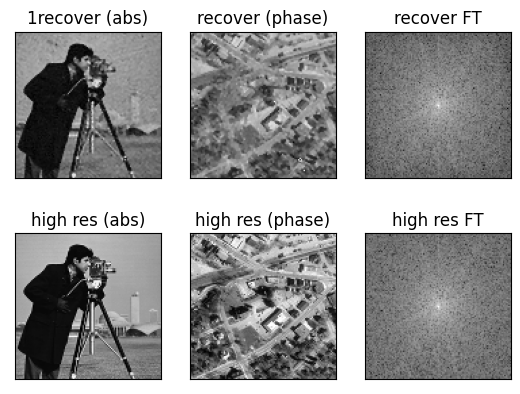

Show Image Sucess!


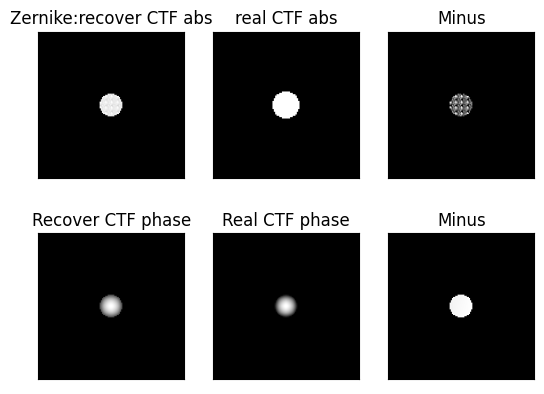

In [13]:
%matplotlib inline
show_result(fpm.OBJ, 1)